<a href="https://colab.research.google.com/github/siwarTaha/Prediction-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title: Prediction of Product Sales

Siwar Ehwass

## Project Overview

### Data Dictionary

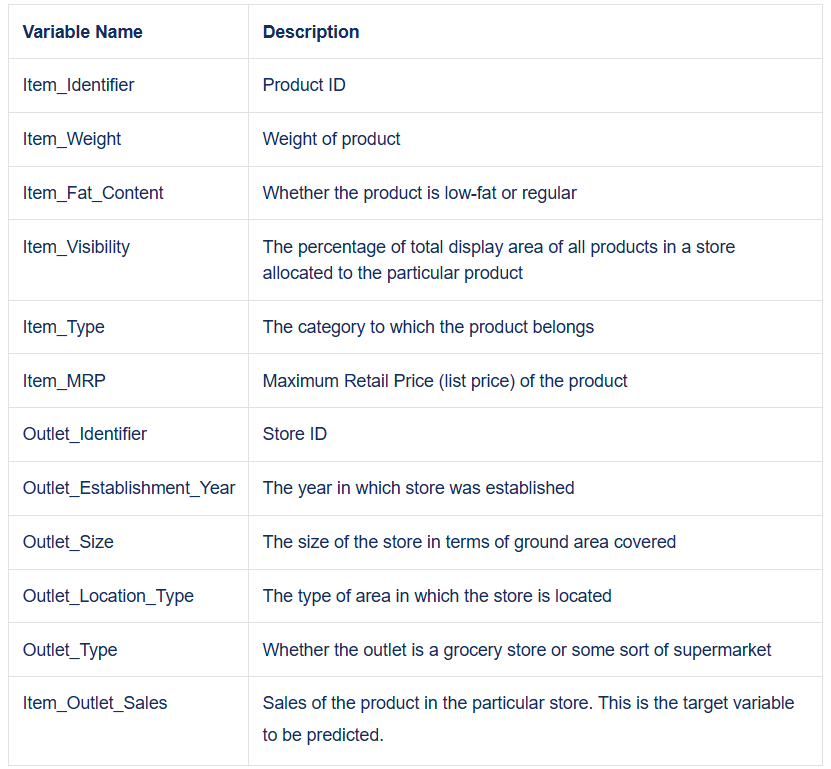

## Load and Inspect Data

### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn import set_config

set_config(transform_output='pandas')

### Loading Data

In [2]:
path='https://docs.google.com/spreadsheets/d/e/2PACX-1vR6AvAZumX2EE8diEPYfNdktYpa8cELog1Iv_SL7EIFj_DIVxnGwq5liujvJ1GTQry9NDkFsISbeWaE/pub?output=csv'
df=pd.read_csv(path)


In [3]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


### Feature Engineering

The following feature engineering steps have been applied to the `df` DataFrame immediately after loading the data to ensure they are available before the train-test split. This approach handles transformations that do not introduce data leakage (e.g., dropping identifiers, creating features based on existing columns, standardizing categorical values).

*   **`Outlet_Age`**: Calculated as `2026 - Outlet_Establishment_Year`.
*   **`Item_Category`**: Extracted from the first two characters of `Item_Identifier`.
*   **Non-Edible `Item_Fat_Content`**: Items with `Item_Category` 'NC' (Non-Consumable) have their `Item_Fat_Content` standardized to 'Non-Edible'.
*   **`MRP_Level`**: Categorized `Item_MRP` into 'Low', 'Medium', and 'High' bins.
*   **Dropped high-cardinality IDs**: `Item_Identifier` and `Outlet_Identifier` columns were dropped.
*   **Standardized `Item_Fat_Content` values**: Inconsistent values ('LF', 'reg', 'low fat') were standardized to 'Low Fat' and 'Regular'.

In [5]:

# Create Outlet_Age and drop Outlet_Establishment_Year
df['Outlet_Age'] = 2026 - df['Outlet_Establishment_Year']
df.drop(columns=['Outlet_Establishment_Year'], inplace=True)

# Extract Item_Category from Item_Identifier
df['Item_Category'] = df['Item_Identifier'].str[:2]

# Set non-consumable items to 'Non-Edible' fat content
df.loc[df['Item_Category'] == 'NC', 'Item_Fat_Content'] = 'Non-Edible'

# Create price categories
df['MRP_Level'] = pd.cut(
    df['Item_MRP'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

# Drop Item_Identifier and Outlet_Identifier (already handled earlier, ensuring Item_Category was extracted first)
df.drop(columns=['Item_Identifier','Outlet_Identifier'], inplace=True)

# Replace inconsistent Item_Fat_Content values (already done, but ensure 'Non-Edible' is not overwritten)
df['Item_Fat_Content']=df['Item_Fat_Content'].replace({'LF':'Low Fat',
                                             "low fat":'Low Fat',
                                             'reg':'Regular'})

### Train test split

In [6]:
# target column
y= df['Item_Outlet_Sales']
X= df.drop(columns='Item_Outlet_Sales')

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Replace 0s in Item_Visibility with np.nan for imputation by pipeline
X_train.loc[X_train['Item_Visibility'] == 0, 'Item_Visibility'] = np.nan
X_test.loc[X_test['Item_Visibility'] == 0, 'Item_Visibility'] = np.nan

### Handling `Item_Visibility` and `Outlet_Size`

To prevent data leakage and align with the constraint of not introducing new libraries like `sklearn.base`:

*   **`Item_Visibility`**: Values of `0` in `Item_Visibility` are treated as missing data (`np.nan`) *after* the train-test split for `X_train` and `X_test`. This allows the `SimpleImputer` within the numeric pipeline to handle these `NaN` values (e.g., by median imputation) during model training and evaluation.
*   **`Outlet_Size`**: Missing values in `Outlet_Size` are handled by the `SimpleImputer` (with `fill_value='MISSING'`) within the ordinal preprocessing pipeline, which is applied *after* the train-test split. This ensures that the imputation strategy is learned only from the training data.

- Ordinal: Outet size only
- Nominal:  Everything Else
- Numeric: The rest of the df

## Clean Data

### Duplicated Rows

In [7]:
# check for duplicated data
duplicated_rows=df.duplicated()
duplicated_rows.sum()

np.int64(0)

- there are no duplicated values



### Unique Identifiers

In [8]:
# number of unique values for each column in X_train
print("Unique values in X_train:\n")
X_train.nunique()

print("\nUnique values in X_test:")
X_test.nunique()

Unique values in X_train:

Unique values in X_test:


,0
Item_Weight,356
Item_Fat_Content,3
Item_Visibility,1996
Item_Type,16
Item_MRP,1931
Outlet_Size,3
Outlet_Location_Type,3
Outlet_Type,4
Outlet_Age,9
Item_Category,3


In [9]:
# percentage of unique values in each column for X_train
print("Percentage of unique values in X_train:")
X_train.nunique() / len(X_train) * 100

print("\nPercentage of unique values in X_test:")
X_test.nunique() / len(X_test) * 100

Percentage of unique values in X_train:

Percentage of unique values in X_test:


,0
Item_Weight,16.705772
Item_Fat_Content,0.140779
Item_Visibility,93.664946
Item_Type,0.750821
Item_MRP,90.614735
Outlet_Size,0.140779
Outlet_Location_Type,0.140779
Outlet_Type,0.187705
Outlet_Age,0.422337
Item_Category,0.140779


### Missing Values
- Checking for NaN rows:

In [10]:
# see columns and rows where NaN is present in X_train
X_train.isna()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,Outlet_Age,Item_Category,MRP_Level
4776,False,False,False,False,False,False,False,False,False,False,False
7510,False,False,True,False,False,False,False,False,False,False,False
5828,False,False,False,False,False,False,False,False,False,False,False
5327,False,False,False,False,False,False,False,False,False,False,False
4810,False,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
5734,False,False,False,False,False,True,False,False,False,False,False
5191,False,False,False,False,False,True,False,False,False,False,False
5390,False,False,False,False,False,True,False,False,False,False,False
860,False,False,False,False,False,True,False,False,False,False,False


In [11]:
# check how many rows in each column of X_train has a missing value
null_sums=X_train.isna().sum()
null_sums

,0
Item_Weight,1107
Item_Fat_Content,0
Item_Visibility,400
Item_Type,0
Item_MRP,0
Outlet_Size,1812
Outlet_Location_Type,0
Outlet_Type,0
Outlet_Age,0
Item_Category,0


In [12]:
# check the percentage of null values in X_train
null_percent=null_sums/len(X_train)*100
null_percent[null_percent>0]

,0
Item_Weight,17.318523
Item_Visibility,6.257822
Outlet_Size,28.347935


- 17.16% from Weight column has missing values
- 28.27% from Store size has missing value

#### Inspect Outlet Size

In [13]:
# filter categorical features from X_train
cat_cols=X_train.select_dtypes('object').columns

# filter numerical features from X_train
num_cols=X_train.select_dtypes('number').columns

In [14]:
X_train['Outlet_Size'].value_counts(dropna=False)

,count
Outlet_Size,
Medium,2103
NaN,1812
Small,1788
High,689


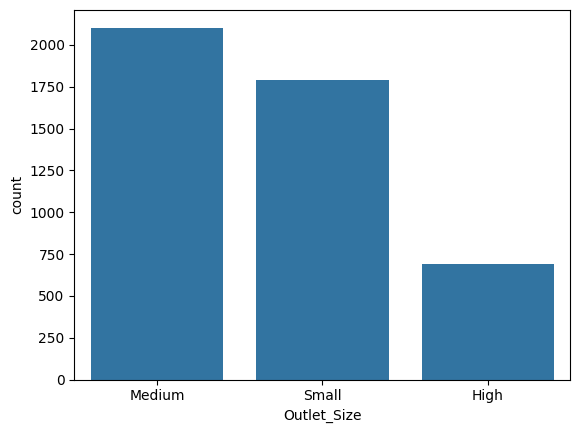

In [15]:
ax=sns.countplot(data=X_train, x='Outlet_Size')

- This graph shows that there are over 2000 Medium and Small Outlets Size while there are less than 1000 High Outlet size.

- Since Outlet_Size is a categorical feature with a large percentage of missing values (~28%):
  - dropping rows would result in significant data loss.
  - Filling with the most frequent category could introduce bias into the distribution.
  - Therefore, replacing missing values with "MISSING" is the most appropriate strategy because it preserves the data

#### Inspecting Item Weight

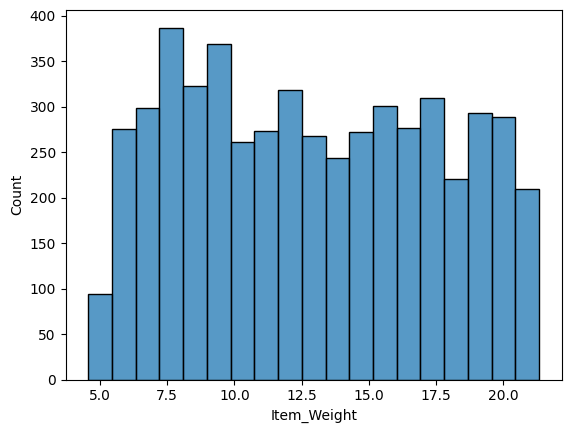

In [16]:
ax = sns.histplot(data=X_train,x='Item_Weight')

- Median is preferred because it is less affected by outliers and preserves the distribution better than using -1 or dropping rows.

- Since Item Weight is a numeric feature, missing values were filled using the median because it is less affected by outliers and helps preserve the overall distribution of the data.

Before filling number columns with placeholder, check describe()

In [17]:
cat_cols_df=X_train.select_dtypes('object').columns
num_cols_df=X_train.select_dtypes('number').columns

In [18]:
# summary of num cols in X_train
for col in num_cols_df:
  print(f'summary of {col}: ')
  print(X_train[col].describe())
  print("\n")

summary of Item_Weight: 
count    5285.000000
mean       12.904458
std         4.637034
min         4.555000
25%         8.895000
50%        12.650000
75%        17.000000
max        21.350000
Name: Item_Weight, dtype: float64


summary of Item_Visibility: 
count    5992.000000
mean        0.070413
std         0.049785
min         0.003575
25%         0.031712
50%         0.058208
75%         0.097916
max         0.328391
Name: Item_Visibility, dtype: float64


summary of Item_MRP: 
count    6392.000000
mean      141.980400
std        62.629276
min        31.290000
25%        94.146200
50%       144.110200
75%       186.900300
max       266.888400
Name: Item_MRP, dtype: float64


summary of Outlet_Age: 
count    6392.000000
mean       28.142835
std         8.392300
min        17.000000
25%        22.000000
50%        27.000000
75%        39.000000
max        41.000000
Name: Outlet_Age, dtype: float64




nothing needs to be addressed, so we fill all null values in num_cols with -1 placeholder:

### Consistent Values

Check each string column's value counts for inconsistent values:


In [19]:
# loop through each categorical/string column in X_train
for col in cat_cols_df:
  print(f'value counts of {col}: ')
  print(X_train[col].value_counts())
  print("\n")

value counts of Item_Fat_Content: 
Item_Fat_Content
Low Fat       2914
Regular       2263
Non-Edible    1215
Name: count, dtype: int64


value counts of Item_Type: 
Item_Type
Fruits and Vegetables    948
Snack Foods              906
Household                695
Frozen Foods             632
Dairy                    507
Canned                   481
Baking Goods             478
Health and Hygiene       390
Soft Drinks              331
Meat                     302
Breads                   175
Hard Drinks              169
Others                   130
Starchy Foods            122
Breakfast                 84
Seafood                   42
Name: count, dtype: int64


value counts of Outlet_Size: 
Outlet_Size
Medium    2103
Small     1788
High       689
Name: count, dtype: int64


value counts of Outlet_Location_Type: 
Outlet_Location_Type
Tier 3    2531
Tier 2    2106
Tier 1    1755
Name: count, dtype: int64


value counts of Outlet_Type: 
Outlet_Type
Supermarket Type1    4166
Grocery Store    

This column has incosistent values:
- Fat Content: LF, reg, low fat

In [20]:
# check for inconsistent values in X_train
X_train['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,2914
Regular,2263
Non-Edible,1215


In [21]:

# Confirm applied changes on X_train (now reflecting pre-split cleaning)
X_train['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,2914
Regular,2263
Non-Edible,1215


### Describe Numeric Data
- min, max, mean

In [22]:
# get numeric columns from X_train
num_cols_df=X_train.select_dtypes('number').columns

# use the describe method and filter using .loc() on X_train
X_train[num_cols_df].describe().loc[['min','max','mean']]

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Age
min,4.555000,0.003575,31.2900,17.000000
max,21.350000,0.328391,266.8884,41.000000
mean,12.904458,0.070413,141.9804,28.142835


## Feature Inspection
- Exploratory Visuals & Analysis

In [23]:
# view X_train data
X_train.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,Outlet_Age,Item_Category,MRP_Level
4776,16.350,Non-Edible,0.029565,Household,256.4646,Medium,Tier 3,Supermarket Type2,17,NC,High
7510,15.250,Regular,NaN,Snack Foods,179.7660,Medium,Tier 3,Supermarket Type2,17,FD,Medium
5828,12.350,Regular,0.158716,Meat,157.2946,Medium,Tier 1,Supermarket Type1,27,FD,Medium
5327,7.975,Low Fat,0.014628,Baking Goods,82.3250,Small,Tier 2,Supermarket Type1,22,FD,Low
4810,19.350,Low Fat,0.016645,Frozen Foods,120.9098,NaN,Tier 2,Supermarket Type1,24,FD,Medium


ax=X_train.hist(figsize=(12,10));

In [24]:
# ax=df[num_cols].hist(figsize=(12,10));
# This cell was using the old 'df' for plotting numerical histograms.
# The relevant data is now in X_train/y_train after the split and initial cleaning.
# The previous cell `gdVL3JvuhTuv` already plots histograms for X_train's numeric columns.
# To avoid confusion and ensure consistency, I'm commenting this out as it's potentially redundant or misleading in the new workflow.

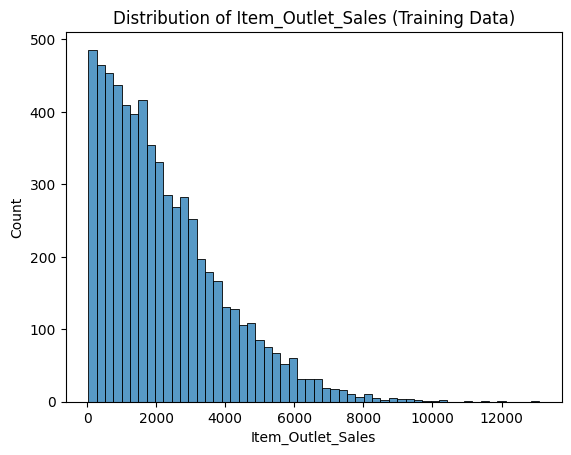

In [25]:
# item outlet sales (from y_train)
ax= sns.histplot(x=y_train)
ax.set_title("Distribution of Item_Outlet_Sales (Training Data)");

- Most items have low visibility.
- Most sales are low, with a few very high sales.
- Item weights are spread out, but many are around 11–13,
  - because we filled the null values with median earlier
- Retail prices vary a lot.
- Outlet establishment years occur at specific years only.

### Boxplot for numeric columns

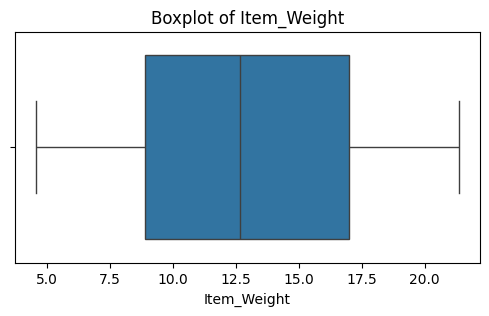

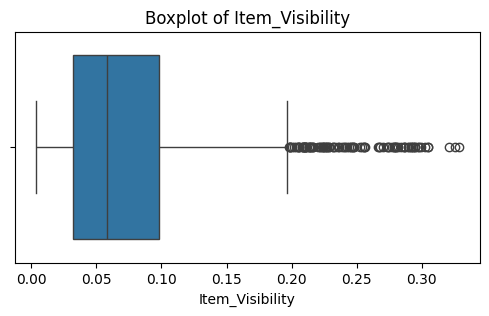

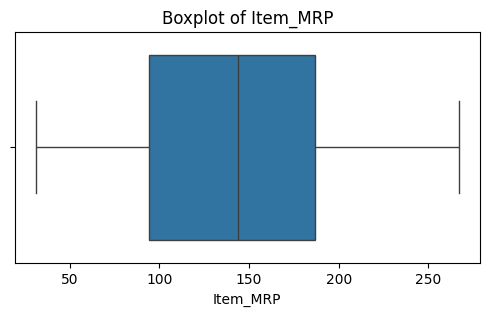

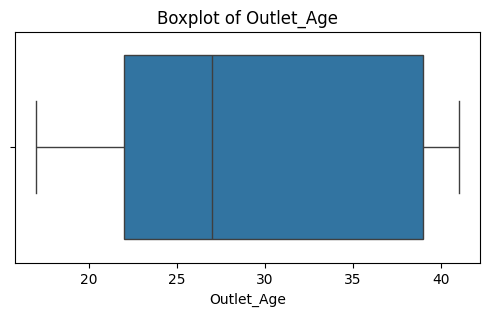

In [26]:
for col in num_cols_df:
    plt.figure(figsize=(6,3))
    ax = sns.boxplot(x=X_train[col])
    ax.set_title(f"Boxplot of {col}")

What we notice from the boxplots:

- Item_Visibility has many outliers (many unusually high values).
- Item_Outlet_Sales also has many high outliers.
- Item_Weight and Maximum Retail Price are more evenly spread.
- Bigger boxes mean more spread in the middle 50% of the data.

### Countplots for Categorical Columns

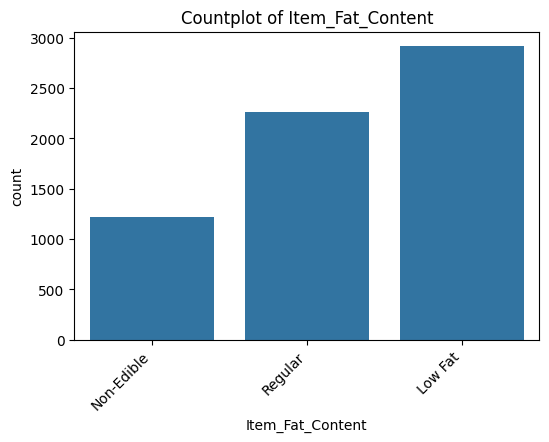

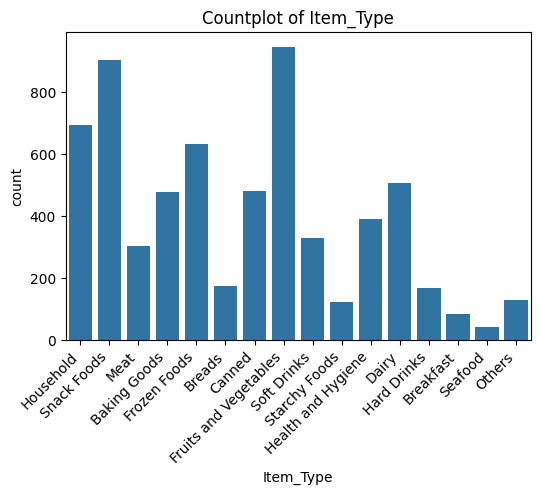

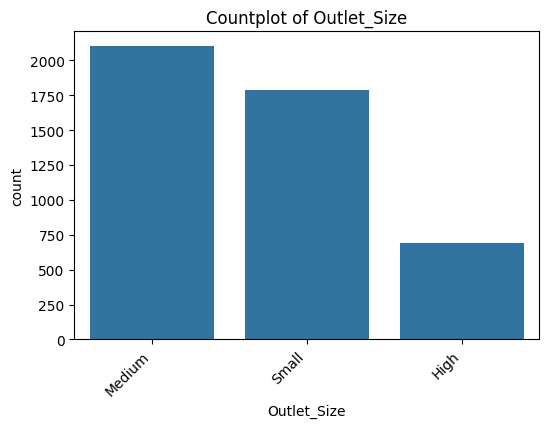

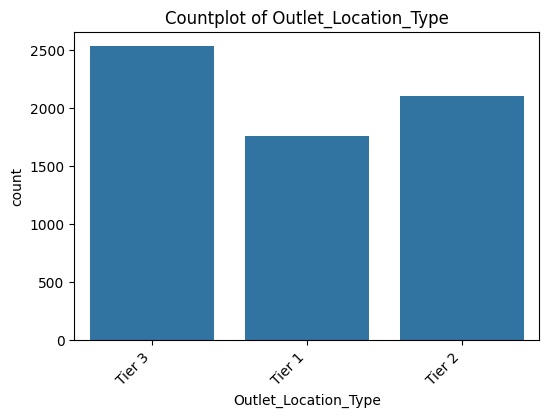

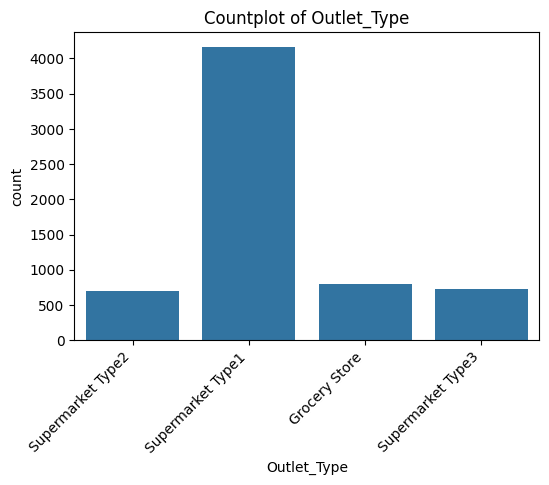

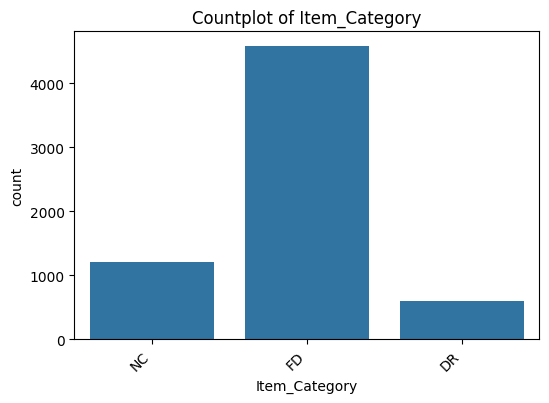

In [27]:
for col in cat_cols_df:
    plt.figure(figsize=(6,4))
    ax = sns.countplot(data=X_train, x=col)
    ax.set_title(f"Countplot of {col}")
    plt.xticks(rotation=45, ha='right');

What we notice from the countplots:

- Low Fat items are more common than Regular items.
- Fruits and Vegetables and Snack Foods are the most common item types.
- Seafood and Breakfast items are the least common.
- Most outlets are Medium or Small in size.
- Tier 3 locations have the most outlets.
- Supermarket Type1 is much more common than the other outlet types.

### Correlation Heatmap


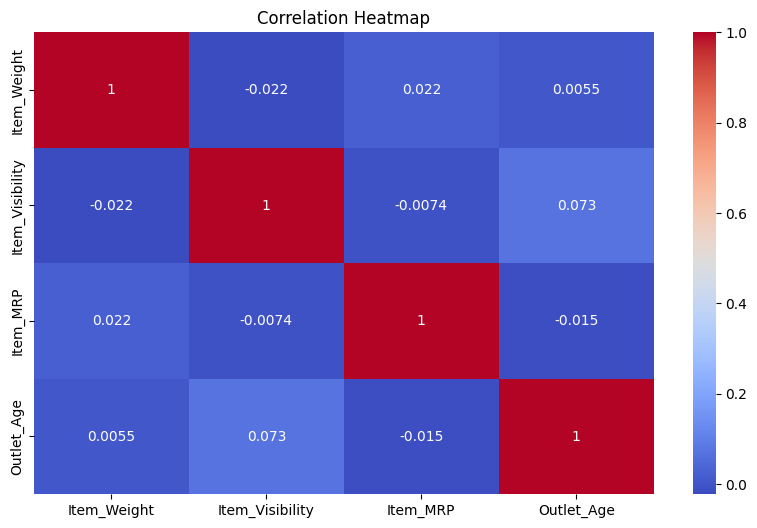

In [28]:
corr = X_train.corr(numeric_only=True)
plt.figure(figsize=(10,6))
ax = sns.heatmap(corr, annot=True, cmap='coolwarm')
ax.set_title("Correlation Heatmap");

### Regression Plot: Maximum Retail Price & Item Outlet Sales

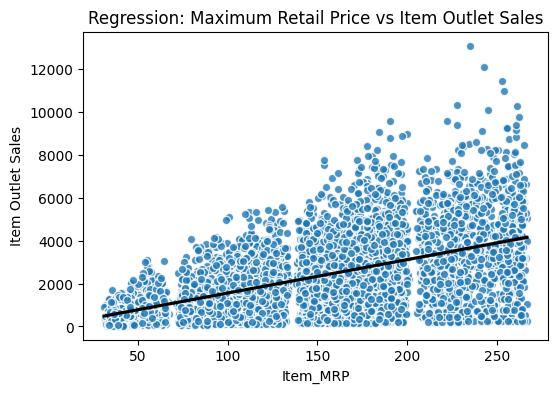

In [29]:
plt.figure(figsize=(6,4))
line_kws = dict(color='black')
scatter_kws = dict(edgecolor='white')

# To correctly plot Item_MRP vs Item_Outlet_Sales, we need to combine X_train and y_train for the plot.
# Alternatively, we can ensure the data passed to sns.regplot contains both columns.
# Since y_train is a Series, we can plot against Item_MRP from X_train directly if indices align.

# Create a temporary DataFrame for plotting if necessary, or ensure direct access
plot_df = pd.DataFrame({'Item_MRP': X_train['Item_MRP'], 'Item_Outlet_Sales': y_train})

ax = sns.regplot(
    data=plot_df,
    x='Item_MRP',
    y='Item_Outlet_Sales',
    line_kws=line_kws,
    scatter_kws=scatter_kws
)

ax.set(
    xlabel="Item_MRP",
    ylabel="Item Outlet Sales",
    title="Regression: Maximum Retail Price vs Item Outlet Sales"
);

- There is a positive relationship between Maximum Retail Price and Item Outlet Sales. As retail price increases, sales tend to increase as well.

### Countplot of Item Type

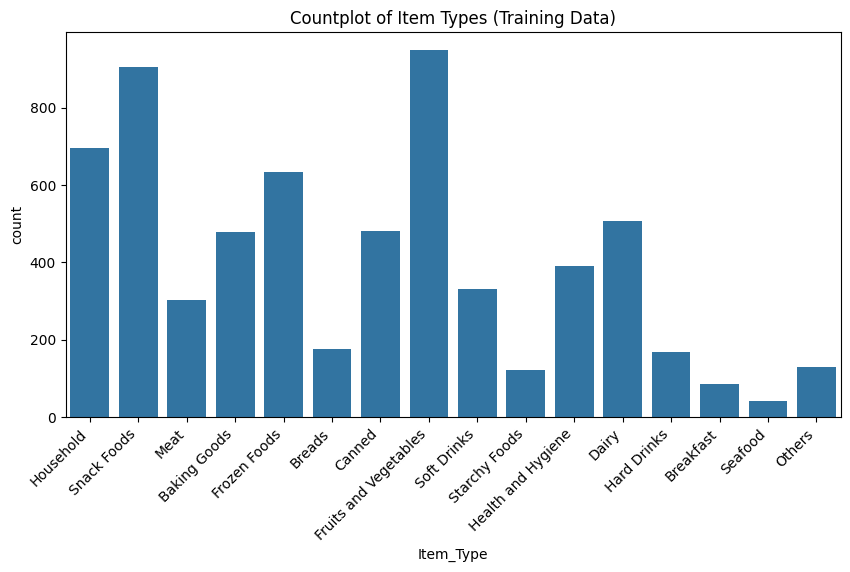

In [30]:
plt.figure(figsize=(10,5))

ax = sns.countplot(data=X_train, x='Item_Type')

ax.set_title("Countplot of Item Types (Training Data)");

plt.xticks(rotation=45, ha='right');

- Fruits and Vegetables and Snack Foods are the most common item categories, while Seafood and Breakfast items appear least frequently.

# inspect X_train
X_train.head()

In [31]:
# inspect data
X_train.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,Outlet_Age,Item_Category,MRP_Level
4776,16.350,Non-Edible,0.029565,Household,256.4646,Medium,Tier 3,Supermarket Type2,17,NC,High
7510,15.250,Regular,NaN,Snack Foods,179.7660,Medium,Tier 3,Supermarket Type2,17,FD,Medium
5828,12.350,Regular,0.158716,Meat,157.2946,Medium,Tier 1,Supermarket Type1,27,FD,Medium
5327,7.975,Low Fat,0.014628,Baking Goods,82.3250,Small,Tier 2,Supermarket Type1,22,FD,Low
4810,19.350,Low Fat,0.016645,Frozen Foods,120.9098,NaN,Tier 2,Supermarket Type1,24,FD,Medium


In [32]:
# view strings and categorical data
cat_cols_df=X_train.select_dtypes('object').columns
X_train[cat_cols_df]

,Item_Fat_Content,Item_Type,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Category
4776,Non-Edible,Household,Medium,Tier 3,Supermarket Type2,NC
7510,Regular,Snack Foods,Medium,Tier 3,Supermarket Type2,FD
5828,Regular,Meat,Medium,Tier 1,Supermarket Type1,FD
5327,Low Fat,Baking Goods,Small,Tier 2,Supermarket Type1,FD
4810,Low Fat,Frozen Foods,NaN,Tier 2,Supermarket Type1,FD
...,...,...,...,...,...,...
5734,Regular,Fruits and Vegetables,NaN,Tier 3,Grocery Store,FD
5191,Low Fat,Frozen Foods,NaN,Tier 2,Supermarket Type1,FD
5390,Non-Edible,Health and Hygiene,NaN,Tier 2,Supermarket Type1,NC
860,Low Fat,Snack Foods,NaN,Tier 2,Supermarket Type1,FD


### Ordinal Pipleline

In [33]:
# see value counts for possible ordinal features
ord_cols=['Outlet_Size']
X_train[ord_cols].value_counts(dropna=False)

,count
Outlet_Size,
Medium,2103
NaN,1812
Small,1788
High,689


In [34]:
# order cats
size_order=['MISSING','Small','Medium','High']
# Pipeline
ord_pipe = make_pipeline(
  SimpleImputer(strategy='constant', fill_value='MISSING'),
  OrdinalEncoder(categories=[size_order]),
  StandardScaler()
)
ord_tuple = ('Ordinal', ord_pipe, ord_cols)

ord_pipe

Pipeline(steps=[('simpleimputer',
                 SimpleImputer(fill_value='MISSING', strategy='constant')),
                ('ordinalencoder',
                 OrdinalEncoder(categories=[['MISSING', 'Small', 'Medium',
                                             'High']])),
                ('standardscaler', StandardScaler())])

### Nominal

In [35]:
ohe_cols = X_train.select_dtypes('object').drop(columns=ord_cols).columns
ohe_pipe = make_pipeline(
  SimpleImputer(strategy='constant', fill_value='NA'),
  OneHotEncoder(sparse_output=False, handle_unknown='ignore')
)

ohe_tuple = ('Categorical', ohe_pipe, ohe_cols)
ohe_pipe

Pipeline(steps=[('simpleimputer',
                 SimpleImputer(fill_value='NA', strategy='constant')),
                ('onehotencoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

### Numeric

In [36]:
num_cols_train= make_column_selector(dtype_include="number")
# Item_Visibility's 0s are now replaced with np.nan before this pipeline step
num_pipe = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())
num_tuple = ('Numeric', num_pipe, num_cols_train)

num_pipe

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

### Creating Preprocessor

In [37]:
preprocessor = ColumnTransformer(
  [num_tuple, ord_tuple, ohe_tuple],
  verbose_feature_names_out=False
)

### Model Evaluation Function

In [38]:

def regression_metrics(y_true, y_pred, label='', verbose = True, output_dict=False):
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = mse ** 0.5
  r_squared = r2_score(y_true, y_pred)
  if verbose == True:
    header = "-"*60
    print(header, f"Regression Metrics: {label}", header, sep='\n')
    print(f"- MAE = {mae:,.3f}")
    print(f"- MSE = {mse:,.3f}")
    print(f"- RMSE = {rmse:,.3f}")
    print(f"- R^2 = {r_squared:,.3f}")
  if output_dict == True:
      metrics = {'Label':label, 'MAE':mae,
                 'MSE':mse, 'RMSE':rmse, 'R^2':r_squared}
      return metrics

def evaluate_regression(reg, X_train, y_train, X_test, y_test, verbose = True,
                        output_frame=False):
  y_train_pred = reg.predict(X_train)

  results_train = regression_metrics(y_train, y_train_pred, verbose = verbose,
                                     output_dict=output_frame,
                                     label='Training Data')
  print()
  y_test_pred = reg.predict(X_test)
  results_test = regression_metrics(y_test, y_test_pred, verbose = verbose,
                                  output_dict=output_frame,
                                    label='Test Data' )

  if output_frame:
    results_df = pd.DataFrame([results_train,results_test])
    results_df = results_df.set_index('Label')
    results_df.index.name=None
    return results_df.round(3)

## Model: Linear Regression

In [39]:
# linear regression

linreg_pipe = make_pipeline(preprocessor, LinearRegression())

# Fit on raw training data
linreg_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('Numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7a75b9035880>),
                                                 ('Ordinal',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 stra...
                                                 ('Categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='NA',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Location_Type', 'Outlet_Type',
       'Item_Category'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('linearregression', LinearRegression())])

In [40]:
evaluate_regression(linreg_pipe, X_train, y_train, X_test, y_test, output_frame=True)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 847.252
- MSE = 1,298,229.501
- RMSE = 1,139.399
- R^2 = 0.561

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 804.517
- MSE = 1,195,485.790
- RMSE = 1,093.383
- R^2 = 0.567


,MAE,MSE,RMSE,R^2
Training Data,847.252,1298229.501,1139.399,0.561
Test Data,804.517,1195485.790,1093.383,0.567


- The model does not appear to be overfit or underfit.
- The training R^2 (0.561) and test R^2 (0.567) are very close, indicating that it generalizes well to unseen data. However, since both values are only around 0.56, the model provides a moderate fit and could potentially be improved with better features or a more complex model

## Model: Random Forest

In [41]:
rf = RandomForestRegressor(random_state=42)
rf_pipe = make_pipeline(preprocessor, rf)

rf_pipe.fit(X_train, y_train)
evaluate_regression(rf_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 299.265
- MSE = 186,952.377
- RMSE = 432.380
- R^2 = 0.937

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 777.214
- MSE = 1,248,588.066
- RMSE = 1,117.402
- R^2 = 0.547


- The Random Forest model is overfitting. Its training R^2 score (0.938) is much higher than its test (0.550), meaning that it has memorized the training data and does not generalize as well to new data

- Although the Random Forest has a slightly lower MAE, the Linear Regression model has better overall test performance because it has:
  - Lower MSE
  - Lower RMSE
  - Higher R²

### Tuning with GridCV

In [42]:
rf_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('Numeric',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='median')),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    <sklearn.compose._column_transformer.make_column_selector object at 0x7a75b9035880>),
                                   ('Ordinal',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(fill_value='MISSING',
                                                                   strategy='constant')),
                                                    ('ordinalencoder',
                                                     O...
                                                     

In [43]:
params = {
    'randomforestregressor__max_depth': [None,5, 10, 15, 20],
    'randomforestregressor__n_estimators': [ 100, 150, 200, 300, 500],
    'randomforestregressor__min_samples_leaf': [1, 2, 4,6],
    'randomforestregressor__max_features': ['sqrt', 'log2', None],
    'randomforestregressor__oob_score': [True, False],
    'randomforestregressor__min_samples_split': [2, 5, 10]
}

# 5x5x4x3x2x3 = 1800 combinations x 3 folds = 5400 fits

gridsearch = GridSearchCV(rf_pipe, params, n_jobs=-1, cv=3, verbose=1)
gridsearch.fit(X_train, y_train)

print('\n',gridsearch.best_params_,'\n')

# Best model
best_rf = gridsearch.best_estimator_
evaluate_regression(best_rf, X_train, y_train, X_test, y_test)

Fitting 3 folds for each of 1800 candidates, totalling 5400 fits

 {'randomforestregressor__max_depth': 5, 'randomforestregressor__max_features': None, 'randomforestregressor__min_samples_leaf': 2, 'randomforestregressor__min_samples_split': 2, 'randomforestregressor__n_estimators': 100, 'randomforestregressor__oob_score': True} 

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 755.505
- MSE = 1,152,234.495
- RMSE = 1,073.422
- R^2 = 0.611

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 728.641
- MSE = 1,096,798.476
- RMSE = 1,047.281
- R^2 = 0.602


## Model Recommendation

I recommend using the tuned Random Forest model because it achieved similar performance on both the training and test data, indicating that it generalizes well to unseen data and does not show significant overfitting.

### R-squared Interpretation (Non-Technical)

The model has an R² score of approximately 0.60 on the test set. This means it can explain about 60% of the differences in sales values. While it is not perfect, it captures a substantial amount of the underlying patterns in the data and provides reasonably accurate predictions.

### Additional Metric: MAE (Mean Absolute Error)

The test MAE is approximately **729**, meaning that, on average, the model's predictions differ from the actual sales values by about **729 units**.

### Why MAE?

I selected MAE because it is easy for non-technical stakeholders to understand. It expresses the prediction error in the same units as the target variable and directly answers the question: "On average, how far off are the predictions?"

### Overfitting / Underfitting

The training R² (0.611) and test R² (0.602) are very close, with only a small difference. This indicates that the model is **not significantly overfitting** and generalizes well to new data. However, since both scores are only around 0.60, the model may still be **slightly underfitting**, suggesting that there is room for improvement by adding better features or trying more advanced models.